# Healthcare Predictive Analytics – Disease Detection

## Project Goal
Build machine-learning classification models to predict a patient's **Medical Condition** using healthcare records.

### Objectives
- Perform data cleaning and preprocessing
- Normalize numerical medical records
- Apply classification models
- Compare model performance
- Analyze feature importance
- Discuss ethical data handling and patient privacy


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load Dataset

In [2]:

df = pd.read_csv("healthcare_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 3. Exploratory Data Analysis

In [3]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nSummary Statistics:")
display(df.describe(include='all').T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,55500,49992,DAvId muNoZ,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,55500.0,NaN,NaN,NaN,51.539459,19.602454,13.0,35.0,52.0,68.0,89.0
Gender,55500,2,Male,27774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Type,55500,8,A-,6969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Condition,55500,6,Arthritis,9308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Admission,55500,1827,2024-03-16,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doctor,55500,40341,Michael Smith,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital,55500,39876,LLC Smith,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insurance Provider,55500,5,Cigna,11249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Billing Amount,55500.0,NaN,NaN,NaN,25539.316097,14211.454431,-2008.49214,13241.224652,25538.069376,37820.508436,52764.276736


## 4. Data Cleaning and Privacy-Aware Feature Selection

In [4]:

for col in ['Date of Admission', 'Discharge Date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

#  length of stay
df['Length_of_Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days


df = df.drop_duplicates()

# Drop direct identifiers and sensitive administrative fields.
# These fields are not useful for a generalizable predictive model and can increase privacy risk.
columns_to_drop = [
    'Name',
    'Doctor',
    'Hospital',
    'Date of Admission',
    'Discharge Date'
]

df_model = df.drop(columns=columns_to_drop, errors='ignore').copy()

# Remove rows with missing target
df_model = df_model.dropna(subset=['Medical Condition'])

print("Cleaned Dataset Shape:", df_model.shape)
df_model.head()


Cleaned Dataset Shape: (54966, 11)


,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Room Number,Admission Type,Medication,Test Results,Length_of_Stay
0,30,Male,B-,Cancer,Blue Cross,18856.281306,328,Urgent,Paracetamol,Normal,2
1,62,Male,A+,Obesity,Medicare,33643.327287,265,Emergency,Ibuprofen,Inconclusive,6
2,76,Female,A-,Obesity,Aetna,27955.096079,205,Emergency,Aspirin,Normal,15
3,28,Female,O+,Diabetes,Medicare,37909.782410,450,Elective,Ibuprofen,Abnormal,30
4,43,Female,AB+,Cancer,Aetna,14238.317814,458,Urgent,Penicillin,Abnormal,20


## 5. Target Distribution

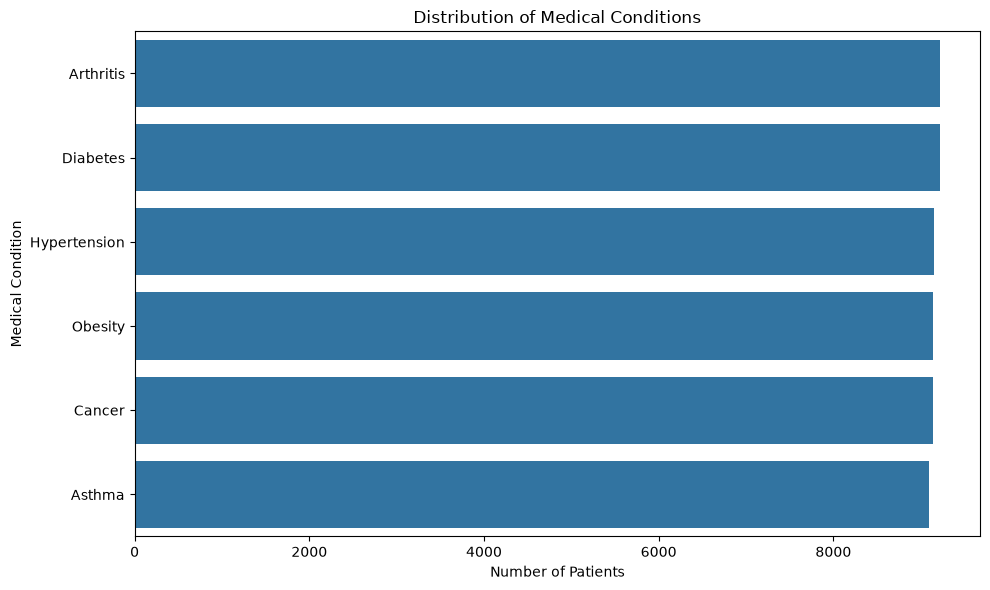

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(10, 6))
order = df_model['Medical Condition'].value_counts().index
sns.countplot(data=df_model, y='Medical Condition', order=order)
plt.title('Distribution of Medical Conditions')
plt.xlabel('Number of Patients')
plt.ylabel('Medical Condition')
plt.tight_layout()
plt.show()

print(df_model['Medical Condition'].value_counts())


## 6. Feature Engineering and Model Preparation

In [6]:
# Target variable
target = 'Medical Condition'

# To reduce target leakage, Medication and Test Results are excluded because
# they may be determined after or alongside clinical diagnosis.
leakage_columns = ['Medication', 'Test Results']

X = df_model.drop(columns=[target] + leakage_columns, errors='ignore')
y = df_model[target]

print("Features used:", list(X.columns))
print("\nTarget classes:", y.unique())

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical Features:", numeric_features)
print("Categorical Features:", categorical_features)


Features used: ['Age', 'Gender', 'Blood Type', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Length_of_Stay']

Target classes: ['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']

Numerical Features: ['Age', 'Billing Amount', 'Room Number', 'Length_of_Stay']
Categorical Features: ['Gender', 'Blood Type', 'Insurance Provider', 'Admission Type']


## 7. Train-Test Split and Normalization

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Numerical pipeline: imputation + normalization
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)


Training Set: (43972, 8)
Testing Set: (10994, 8)


## 8. Logistic Regression Model

In [8]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_pred)

print("Logistic Regression Accuracy:", round(logistic_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, logistic_pred, target_names=label_encoder.classes_))


Logistic Regression Accuracy: 16.32 %

Classification Report:
              precision    recall  f1-score   support

   Arthritis       0.16      0.13      0.14      1844
      Asthma       0.15      0.08      0.11      1819
      Cancer       0.17      0.18      0.17      1828
    Diabetes       0.16      0.22      0.19      1844
Hypertension       0.16      0.22      0.19      1830
     Obesity       0.17      0.15      0.16      1829

    accuracy                           0.16     10994
   macro avg       0.16      0.16      0.16     10994
weighted avg       0.16      0.16      0.16     10994



## 9. Random Forest Classification Model

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))


## 10. Model Comparison

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [logistic_accuracy, rf_accuracy]
})

display(results)

plt.figure(figsize=(8, 5))
sns.barplot(data=results, x='Model', y='Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 11. Confusion Matrix for the Best Model

In [ ]:
best_model = rf_model if rf_accuracy >= logistic_accuracy else logistic_model
best_pred = rf_pred if rf_accuracy >= logistic_accuracy else logistic_pred
best_model_name = 'Random Forest' if rf_accuracy >= logistic_accuracy else 'Logistic Regression'

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f'Confusion Matrix – {best_model_name}')
plt.xlabel('Predicted Condition')
plt.ylabel('Actual Condition')
plt.tight_layout()
plt.show()


## 12. Feature Importance Analysis

In [ ]:
# Extract feature importance from Random Forest
fitted_preprocessor = rf_model.named_steps['preprocessor']
fitted_classifier = rf_model.named_steps['classifier']

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_classifier.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_features = importance_df.head(15)

display(top_features)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_features, x='Importance', y='Feature')
plt.title('Top 15 Important Features for Disease Prediction')
plt.tight_layout()
plt.show()
